# Notch Bridge Response Simulations using Resonance Sweeping and Realistic Libraries (DO NOT EDIT!)

As the next experiment after the second BVD notebook, this notebook will discuss resonance sweeping applied to bridges built using realistic notch filters. It forms the primary experiment before the final cost function improvements, reducing the dimensionality of the optimalization problem.

First, we import our modules:

In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_v2 import Bridge

import numpy as np
import matplotlib.pyplot as plt

Next, we iniate our beam libraries and plot the impedance of the beam it containes:

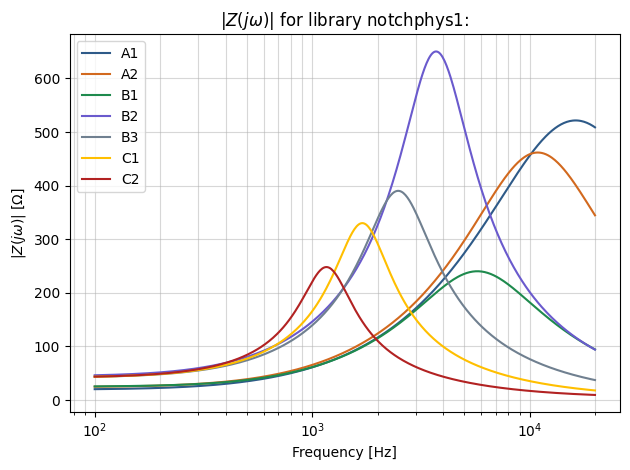

In [2]:
library_name = 'notchphys1'
library = open_beam_library(library_name + '.json')

fig, ax = plt.subplots()
colors = ['#2E5A88', '#D2691E', "#1E8A4D", '#6A5ACD', '#708090', '#FFBF00', '#B22222']
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)
f_start, f_stop = f_logrange
f_arr = np.logspace(f_start, f_stop, 500)

for beam, color in zip(list(library.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper left')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

Note that for our new libraries, we use the rule of thumb:

- $10\, \mu H < L < 1\, mH$
- $1\, nF < C < 100\, \mu F$

We will start with the triangle, like before. Since we do not yet have the mydaq succesfully attached, measurement results will be simulated using `solve_U` with the `noise = True` parameter:

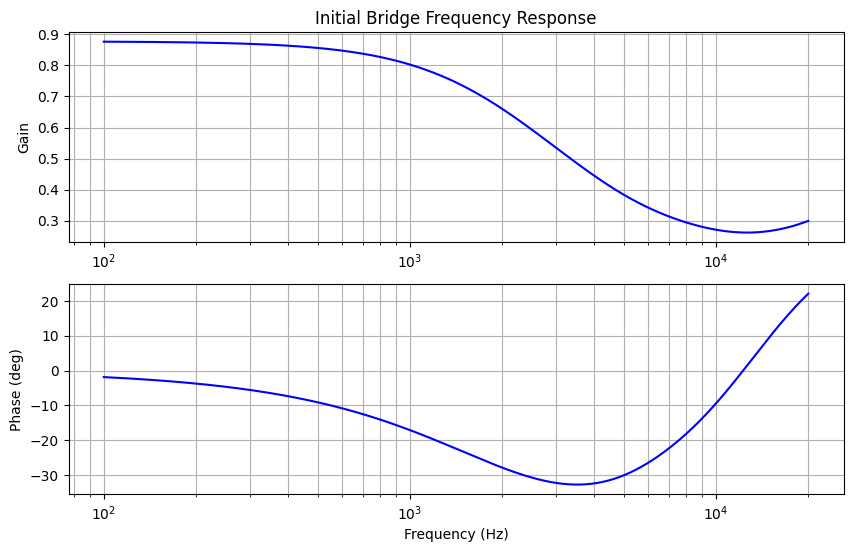

In [3]:
triangle_selection = ['A1', 'A2', 'B1']
triangle_lib = sublibrary(triangle_selection, library)

R_ref = 100 # Ohm
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

# Initialize RNG:
abs_noise = 1e-3
rng = np.random.default_rng(seed=42)
sigma = 0.0 

# A triangle with A in the floor, B inclined at the left and a C at the right:
triangle_topology = [(0, 2), (0, 1), (1, 2)]
triangle = Bridge()
triangle.construct(triangle_lib, triangle_topology)

# Initial beam response:
U_initial = triangle.initial_response(f_arr, R_ref, plot = True)

Using `predict_R`, we can try to predict the resistance values for a slightly deformed triangle:

Targeting 1 base features at (Hz): [12626.6]
Targeting 2 diff features at (Hz): [ 1669.3 13318.4]
R-values found, generating plot...
The correct R values were [470.0, 500.0, 440.0], and the solver predicted [468.76736623 502.39522575 448.37468166].


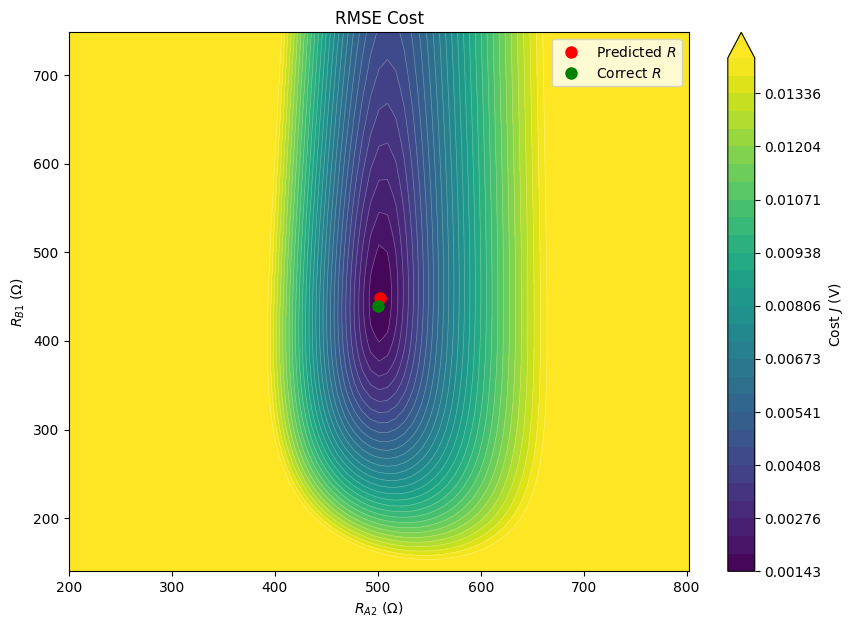

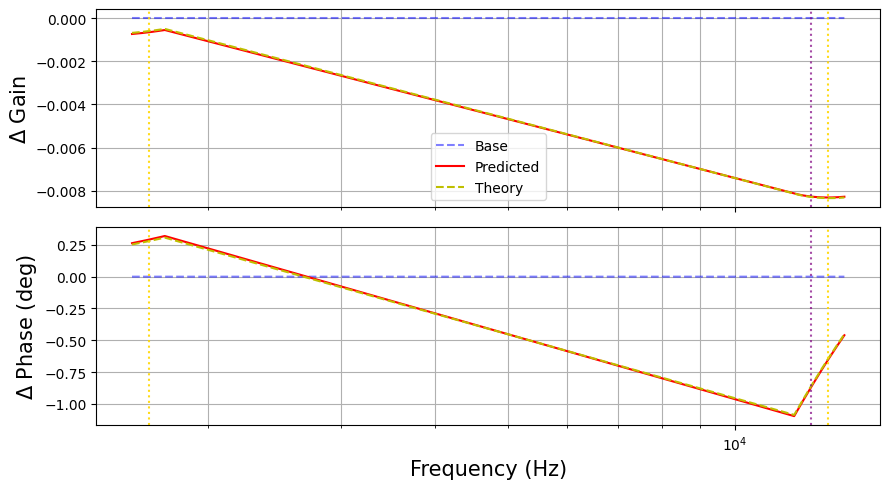

In [4]:
# We will predict the R values for a slightly deformed beam:
R_triangle = [4.7e2, 5.0e2, 4.4e2]

R_triangle_pred = triangle.predict_R(R_ref, myDAQ=False, freqsteps=1500, resonance_sweep=True, rel_df=0.05, noise=True, 
                         abs_noise=abs_noise, sigma=sigma, rng=rng, error_plot=True, R_var=[1,2], R_def=R_triangle, response_comparison_plot=True)


print(f'The correct R values were {R_triangle}, and the solver predicted {R_triangle_pred}.')

Next, we continue our experiment on the advanced bridge structure. We will apply the resonance sweep function to increase the accuracy of our results. First, we construct the bridge and inspect the initial frequency response.

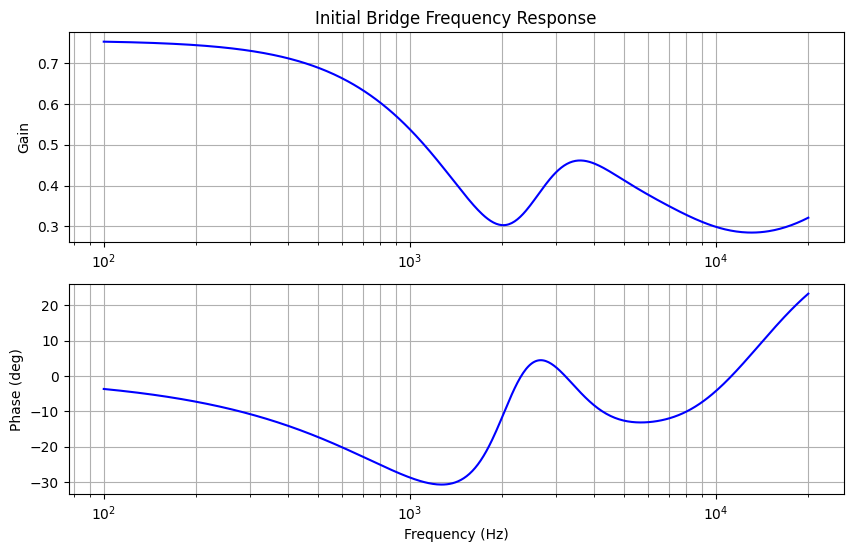

In [5]:
bridge_selection = ['A1', 'A2', 'B1', 'B2', 'C1']
bridge_lib = sublibrary(bridge_selection, library)

# A more advanced bridge structure:
#    2
# 0  1  3

bridge_topology = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
bridge = Bridge()
bridge.construct(bridge_lib, bridge_topology)

U_initial = bridge.initial_response(f_arr, R_ref, plot = True)

Using `predict_R` to try and find deformation values:

Targeting 3 base features at (Hz): [ 2017.3  3595.5 13048.3]
Targeting 3 diff features at (Hz): [ 1967.3  3268.4 13370.3]
R-values found, generating plot...
The correct R values were [500.0, 530.0, 500.0, 440.0, 410.0], and the solver predicted [498.67908251 531.25487168 495.44238504 440.17487512 409.80149714].


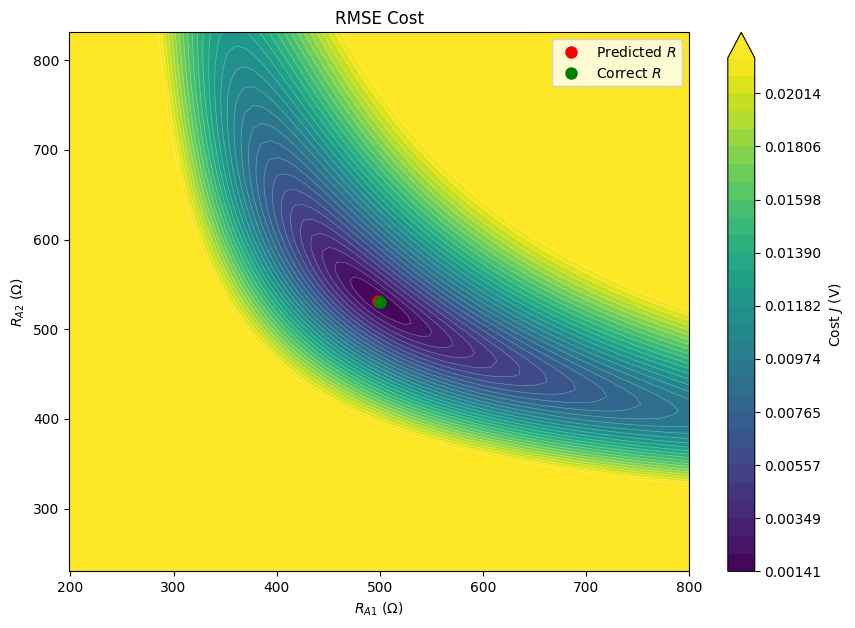

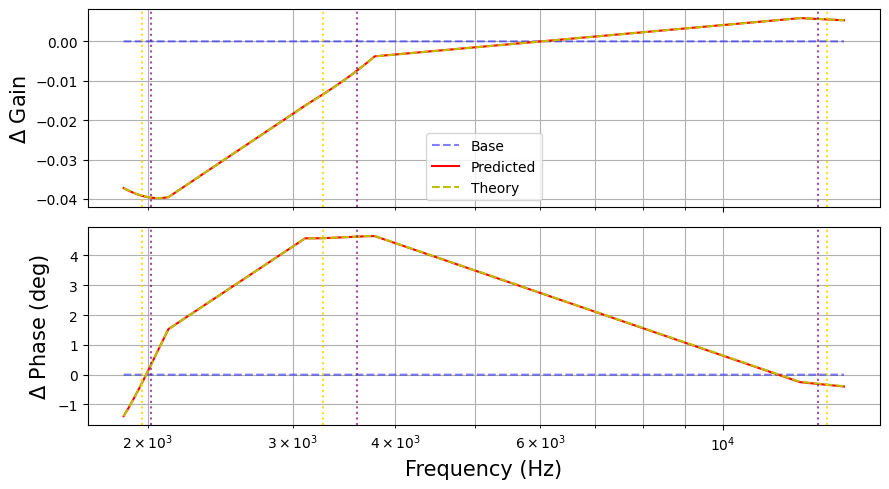

In [6]:
# Let's pretend a force acting on the top node, pointed to the right.
R_bridge = [5.0e2, 5.3e2, 5.0e2, 4.4e2, 4.1e2]

R_bridge_pred = bridge.predict_R(R_ref, myDAQ=False, freqsteps=1500, resonance_sweep=True, rel_df=0.05, noise=True, 
                         abs_noise=abs_noise, sigma=sigma, rng=rng, error_plot=True, R_var=[0,1], R_def=R_bridge, response_comparison_plot=True)

print(f'The correct R values were {R_bridge}, and the solver predicted {R_bridge_pred}.')

An important observations was made: only relative noise causes the solver to fail!